# Stock et al. 2008

So the general Structure is

N -> P1, P2, P3 -> Z1, Z2, Z3, Z4 -> higher order mortality

Basically, I can use the Banas setup, and then adjust the equations and number of P and Z

In [4]:
# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import xso

In [5]:
@xso.component
class Nutrient:
    """XSO component to define a state variable in the model."""
    value = xso.variable(description='nutrient concentration',
                         attrs={'units': 'mmol N m-3'})


@xso.component
class PhytoSizeSpectrum:
    """XSO component to define an array of state variables in the model.
    Additionally, there is a parameter defined, that stores an array of cell sizes."""

    biomass = xso.variable(dims='phyto', description='phytoplankton biomass',
                           attrs={'units': 'mmol N m-3', 'long_name': 'Phytoplankton biomass concentration',
                                  'standard_name': 'Phytoplankton'})
    phyto = xso.index(dims='phyto', description='size spectrum of phytoplankton',
                     attrs={'units': 'µm ESD', 'long_name': 'Phytoplankton size classes',
                                   'standard_name': 'P size classes'})


@xso.component
class ZooSizeSpectrum:
    """XSO component to define an array of state variables in the model.
    Additionally, there is a parameter defined, that stores an array of cell sizes."""

    biomass = xso.variable(dims='zoo', description='zooplankton biomass',
                           attrs={'units': 'mmol N m-3', 'long_name': 'Zooplankton biomass concentration',
                                  'standard_name': 'Zooplankton'})
    zoo = xso.index(dims='zoo', description='size spectrum of zooplankton',
                          attrs={'units': 'µm ESD', 'long_name': 'Zooplankton size classes',
                                 'standard_name': 'Z size classes'})

In [6]:
@xso.component
class ConstantExternalNutrient:
    """Component that provides a constant external nutrient
     as a forcing value.
    """

    forcing = xso.forcing(foreign=False, setup_func='forcing_setup', description='external nutrient')
    value = xso.parameter(description='constant value')

    def forcing_setup(self, value):
        """Method that returns forcing function providing the
        forcing value as a function of time."""
        @np.vectorize
        def forcing(time):
            return value

        return forcing

In [20]:
@xso.component
class LinearForcingInput:
    """Non-dimensional linear forcing input flux."""
    var = xso.variable(foreign=True, flux='input', negative=False, description='variable affected by flux')
    forcing = xso.forcing(foreign=True, description='forcing affecting flux')
    rate = xso.parameter(description='linear rate of change')

    @xso.flux
    def input(self, var, forcing, rate):
        """ """
        return forcing * rate


@xso.component
class LinearPhytoMortality:
    """Linear Phytplankton Mortality Flux."""
    var = xso.variable(dims='phyto', foreign=True, flux='mortality', negative=True, description='variable affected by flux')
    rate = xso.parameter(dims='phyto', description='linear rate of mortality')

    @xso.flux(dims='phyto')
    def mortality(self, var, rate):
        """Linear decay function."""
        return var * rate

import numpy as np
@xso.component
class QuadraticZooMortality:
    """Quadratic Zooplankton Mortality Flux."""
    var = xso.variable(foreign=True, dims='zoo', flux='mortality', negative=True, description='variable affected by flux')
    rate = xso.parameter(description='quadratic rate of mortality')

@xso.flux(dims='zoo')
def mortality(self, var, rate):
    """Flux function describing the quadratic mortality of zooplankton
    according to Banas et al. (2011).

    Utilizes the XSO Math module, available at self.m within fluxes,
    to allow for flexible implementation of math functions according
    to solver backend."""
    return rate * var * self.m.sum(var)

In [21]:
@xso.component
class SizebasedGrazingMatrix:
    """Size-based grazing function, adapted from Banas et al. (2011).

    The grazing function defines a complex pair-wise interaction between
    the size-spectra of phytoplankton and zooplankton. The grazing function
    scales with the size of the consumer and the feeding preference of the
    consumer for a given resource size. The grazing function is further
    scaled by the maximum ingestion rate of the consumer and the half-saturation
    constant of grazing.

    It is implemented in two parts. This component calculates the grazing matrix of each
    size class interaction. The second calculates receives the grazing matrix via the
    'group' argument to the flux function, and sums over the matrix to route the fluxes.
    """
    resource = xso.variable(foreign=True, dims='phyto')
    consumer = xso.variable(foreign=True, dims='zoo')
    phiP = xso.parameter(dims=('phyto', 'zoo'), description='feeding preferences')
    Imax = xso.parameter(dims='zoo', description='maximum ingestion rate')
    KsZ = xso.parameter(description='half saturation constant of grazing')

    @xso.flux(group='graze_matrix', dims=('phyto', 'zoo'))
    def grazing(self, resource, consumer, phiP, Imax, KsZ):
        """Here we are using a matrix calculation, to define the pair-wise interaction."""
        PscaledAsFood = phiP / KsZ * resource[:, None] # using np.newaxis to flip the array and create matrix
        FgrazP = Imax * consumer * PscaledAsFood / (1 + self.m.sum(PscaledAsFood, axis=0)) # sum over Zoo
        return FgrazP


@xso.component
class GrossGrowthEfficiency_MatrixGrazing:
    """ Coponent to calculate the grazing fluxes for each of the model variables, adapted from Banas et al. (2011).

    The grazing fluxes are calculated by multiplying the grazing matrix with the
    biomass of the resource. The grazing matrix is calculated by the SizebasedGrazingKernel_Dims

    to N: beta*(1-epsilon)
    to D: 1-beta
    to Z: beta*epsilon
    """
    grazed_resource = xso.variable(dims='phyto', foreign=True, flux='grazing', negative=True)
    assimilated_consumer = xso.variable(dims='zoo', foreign=True, flux='assimilation')
    egested_detritus = xso.variable(foreign=True, flux='egestion')

    f_eg = xso.parameter(description='fraction egested')
    epsilon = xso.parameter(description='net production efficiency')

    @xso.flux(dims='phyto', group_to_arg='graze_matrix')
    def grazing(self, assimilated_consumer, egested_detritus, grazed_resource, graze_matrix, f_eg, epsilon):
        """ """
        out = self.m.sum(graze_matrix, axis=1)
        return out

    @xso.flux(dims='zoo', group_to_arg='graze_matrix')
    def assimilation(self, assimilated_consumer, egested_detritus, grazed_resource, graze_matrix, f_eg, epsilon):
        """ """
        out = self.m.sum(graze_matrix, axis=0) * epsilon
        return out

    @xso.flux(group_to_arg='graze_matrix')
    def egestion(self, assimilated_consumer, egested_detritus, grazed_resource, graze_matrix, f_eg, epsilon):
        """ """
        out = self.m.sum(graze_matrix, axis=None) * (1 - f_eg - epsilon)
        return out

In [22]:
@xso.component
class MonodGrowth_SizeBased:
    """Component that calculates the growth flux of phytoplankton on a singular nutrient,
    based on Michealis-menten kinetics."""

    resource = xso.variable(foreign=True, flux='uptake', negative=True)
    consumer = xso.variable(foreign=True, dims='phyto', flux='uptake', negative=False)

    halfsat = xso.parameter(dims='phyto', description='half-saturation constants')
    mu_max = xso.parameter(dims='phyto', description='maximum growth rates')

    @xso.flux(dims='phyto')
    def uptake(self, resource, consumer, halfsat, mu_max):
        return mu_max * resource / (resource + halfsat) * consumer


# BUILD MODEL

In [23]:
NPxZxSizeBased = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': SizebasedGrazingMatrix,
    'GGE': GrossGrowthEfficiency_MatrixGrazing,

    # Mortality
    'PhytoMortality': LinearPhytoMortality,
    'ZooMortality': QuadraticZooMortality,

    # Forcings
    'N0': ConstantExternalNutrient,
})

# SETUP MODEL

In [24]:
def calculate_sizes(size_min, size_max, num):
    """initializes log spaced array of sizes from ESD size range"""
    numbers = np.array([i for i in range(num)])
    sizes = (np.log(size_max) - np.log(size_min))* numbers / (num-1) + np.log(size_min)
    return np.exp(sizes)

def calculate_zoo_I0(sizes):
    """initializes allometric Zooplankton ingestion rate based on array of sizes (ESD)"""
    return 26 * sizes ** -0.4

def calculate_phyto_mu0(sizes):
    """initializes allometric Phytoplankton maximum growth rate based on array of sizes (ESD)
    allometric relationships are taken from meta-analyses of lab data"""
    return 2.6 * sizes ** -0.45

def calculate_phyto_ks(sizes):
    """initializes allometric Phytoplankton half-saturation constant based on array of sizes (ESD)"""
    return sizes * .1

def calculate_opt_size(sizes):
    """Calculating optimal prey size from Zooplankton sizes"""
    return 0.65 * sizes ** 0.56


def init_phiP(phytosize, zoopreyoptsize):
    """creates matrix of feeding preferences [P...P10] for each [Z]"""
    phiP = np.array([[np.exp(-((np.log10(xpreyi) - np.log10(xpreyoptj)) / 0.25) ** 2)
                      for xpreyi in phytosize] for xpreyoptj in zoopreyoptsize])
    return phiP

In [25]:
# number size classes of phytoplankton and zooplankotn
PZ_num = 40

# create initial biomass
phyto_init = np.tile(.5/PZ_num, (PZ_num))
zoo_init = np.tile(.1/PZ_num, (PZ_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = calculate_sizes(1.,20.,PZ_num)
zoo_sizes = 2.16 * phyto_sizes **1.79 

# ingestion
zoo_I0 = calculate_zoo_I0(zoo_sizes)

# growth
phyto_mu0 = calculate_phyto_mu0(phyto_sizes)
phyto_ks = calculate_phyto_ks(phyto_sizes)

# grazing
preyoptsize = calculate_opt_size(zoo_sizes)
phiP = init_phiP(phyto_sizes, preyoptsize)

In [26]:
model_setup = xso.setup(solver='solve_ivp', model=NPxZxSizeBased,
            time=np.arange(0,365*10),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z',
                               'Imax':zoo_I0, 'KsZ':3., 'phiP':phiP},
                    'GGE':{'grazed_resource':'P', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'epsilon':1./3., 'f_eg':1./3.},
                
                    # Mortality
                    'PhytoMortality':{'var':'P', 'rate':0.1*phyto_mu0},
                    'ZooMortality':{'var':'Z', 'rate':1.},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':1.},
            })

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'clock' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)


# RUN MODEL AND PLOT OUTPUT

In [27]:
from tqdm import tqdm
from xsimlab.monitoring import ProgressBar

with ProgressBar():
    with NPxZxSizeBased:
        model_out = model_setup.xsimlab.run()

███████████████████████████████████████████ 100% | Simulation finished in 00:07 


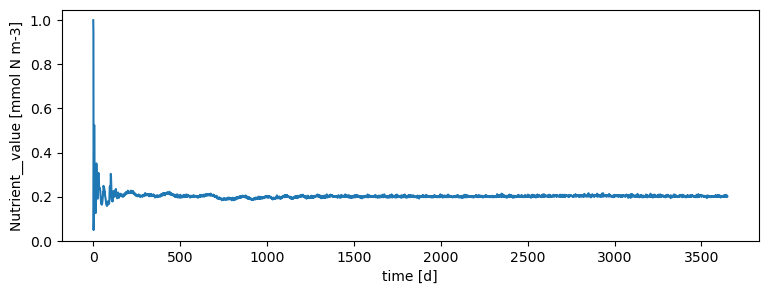

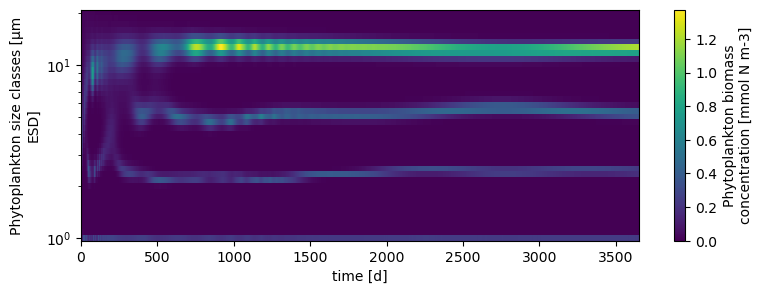

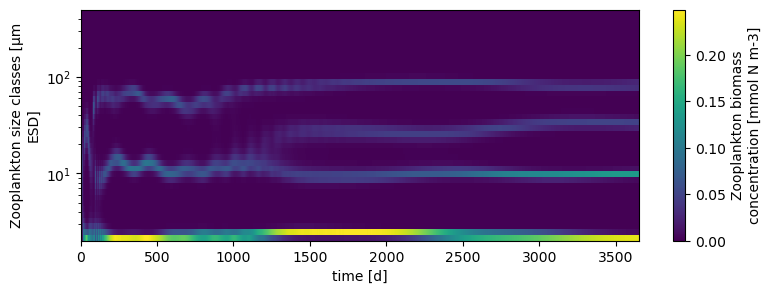

In [28]:
# let's get a quick overivew:

# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

# BUILD NEW MODEL FROM SCRATCH BELOW HERE!

### Modified Components:

In [67]:
@xso.component
class StockPhytoMortality:
    """Linear Phytplankton Mortality Flux."""
    var = xso.variable(dims='phyto', foreign=True, flux='mortality', negative=True, description='variable affected by flux')
    nutrient = xso.variable(foreign=True, flux='recycled_mortality', negative=False, description='recycled mortality to nutrient')
    
    rate = xso.parameter(dims='phyto', description='linear rate of mortality')
    exponent = xso.parameter(dims='phyto', description='allows for conditional quadratic mortality')
    recycling = xso.parameter(dims='phyto', description='amount of mortality going to nutrient')
    
    @xso.flux(dims='phyto')
    def mortality(self, var, nutrient, rate, exponent, recycling):
        """Linear or quadratic decay function."""
        return (var ** exponent) * rate

    @xso.flux
    def recycled_mortality(self, var, nutrient, rate, exponent, recycling):
        """Linear or quadratic decay function."""
        return self.m.sum(var * recycling)

In [68]:
Stocketal2008 = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Mortality
    'PhytoMortality': StockPhytoMortality,

    # Forcings
    'N0': ConstantExternalNutrient,
})

In [69]:
# number size classes of phytoplankton and zooplankton
P_num = 3
Z_num = 4

# create initial biomass
phyto_init = np.tile(.1/P_num, (P_num))
#zoo_init = np.tile(.1/PZ_num, (PZ_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = [0.63, 6.3, 63]
#zoo_sizes = 2.16 * phyto_sizes **1.79 

phyto_ks = [0.062, 0.45, 3.3]
phyto_mu0 = [1, 1.26, 0.42]
phyto_mortality = [1, 0, 0]
phyto_mort_exponent = [2, 1, 1]
phyto_recycling = [1, 0, 0]

In [73]:
model_setup = xso.setup(solver='solve_ivp', model=Stocketal2008,
            time=np.arange(0,50),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},
                
                    # Mortality
                    'PhytoMortality':{'var':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':1.},
            })

In [74]:
Stocketal2008

<xsimlab.Model (9 processes, 21 inputs)>
Core
    solver_type       [in] solver type to use for model
Time
    time_input        [in] ('time',) sequence of time for which to ...
Nutrient
    value_label       [in] label / nutrient concentration
    value_init        [in] initial value / nutrient concentration
Phytoplankton
    biomass_label     [in] label / phytoplankton biomass
    biomass_init      [in] ('phyto',) initial value / phytoplankton...
    phyto_index       [in] ('phyto',) index / size spectrum of phyt...
N0
    forcing_label     [in] label / external nutrient
    value             [in] parameter / constant value
Inflow
    var               [in] label reference / variable affected by flux
    forcing           [in] label reference / forcing affecting flux
    rate              [in] parameter / linear rate of change
Growth
    resource          [in] label reference / 
    consumer          [in] label reference / 
    halfsat           [in] ('phyto',) parameter / half-satur

In [75]:
with Stocketal2008:
        model_out = model_setup.xsimlab.run()

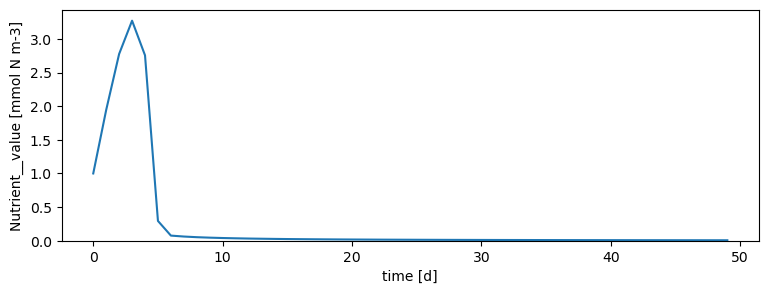

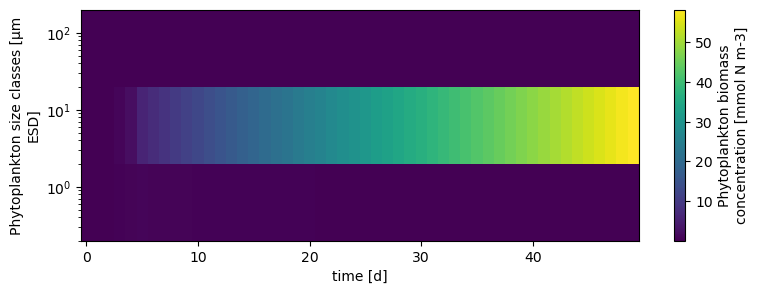

In [76]:
# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)